In [1]:
import jax

# Set CPU as default device
jax.config.update("jax_platform_name", "cpu")


rng_key = jax.random.PRNGKey(0)

import numpy as np
from datasets import load_dataset

mnist_data = load_dataset("mnist")
data_train, data_test = mnist_data["train"], mnist_data["test"]

X_train = np.stack([np.array(example["image"]) for example in data_train])
y_train = np.array([example["label"] for example in data_train])

X_test = np.stack([np.array(example["image"]) for example in data_test])
y_test = np.array([example["label"] for example in data_test])


/root/miniconda3/envs/probjax/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for mnist contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/mnist
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [2]:
import jax.numpy as jnp


def one_hot_encode(x, k):
    "Create a one-hot encoding of x of size k."
    return jnp.array(x[:, None] == jnp.arange(k), dtype=jnp.float32)


@jax.jit
def prepare_data(X, y, num_categories=10):
    y = one_hot_encode(y, num_categories)

    num_examples = X.shape[0]
    num_pixels = 28 * 28
    X = X.reshape(num_examples, num_pixels)
    X = X / 255.0
    with jax.default_device(jax.devices("cpu")[0]):
        X = jnp.array(X)
        y = jnp.array(y)

    return X, y, num_examples


def batch_data(rng_key, data, batch_size, data_size):
    """Return an iterator over batches of data."""
    _, rng_key = jax.random.split(rng_key)
    idx = jax.random.choice(
        key=rng_key, a=jnp.arange(data_size), shape=(batch_size,)
    )
    minibatch = tuple(elem[idx] for elem in data)
    return minibatch


X_train, y_train, N_train = prepare_data(X_train, y_train)
X_test, y_test, N_test = prepare_data(X_test, y_test)

In [144]:
import flax.linen as nn
import jax.scipy.stats as stats


class NN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=512)(x)
        x = nn.relu(x)
        x = nn.Dense(features=256)(x)
        x = nn.relu(x)
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=10)(x)
        return nn.log_softmax(x)


model = NN()


def logprior_fn(params):
    """Compute the value of the log-prior density function."""
    leaves, _ = jax.tree_util.tree_flatten(params)
    flat_params = jnp.concatenate([jnp.ravel(a) for a in leaves])
    return jnp.sum(stats.norm.logpdf(flat_params))


def loglikelihood_fn(params, data):
    """Categorical log-likelihood"""
    X, y = data
    return jnp.sum(y * model.apply(params, X))


@jax.jit
def compute_accuracy(params, X, y):
    """Compute the accuracy of the model.

    To make predictions we take the number that corresponds to the highest
    probability value, which corresponds to a 1-0 loss.

    """
    target_class = jnp.argmax(y, axis=1)
    predicted_class = jnp.argmax(jax.vmap(model.apply, in_axes=(0,None))(params, X), axis=-1)
    return jnp.mean(predicted_class[None,...] == target_class, -1)[0]

In [176]:
from functools import partial

import blackjax
from blackjax.sgmcmc.gradients import grad_estimator

data_size = len(y_train)
batch_size = 128
step_size = 5e-6
num_particles = 10

rng_key, batch_key = jax.random.split(rng_key)

init_keys = jax.random.split(rng_key, num_particles)
params = jax.vmap(model.init)(init_keys, jnp.ones((num_particles,) + (X_train.shape[-1],)))

batches = partial(batch_data,data=(X_train, y_train), batch_size=batch_size, data_size=data_size)

In [177]:
grad_fn = grad_estimator(logprior_fn, loglikelihood_fn, data_size)
kernel = blackjax.sgld.build_kernel()

In [178]:
states = jax.vmap(blackjax.sgld.init)(params)

In [179]:
from functools import partial


@jax.jit
def mcmc_step(rng_key, states):
    key_batch, key_sample = jax.random.split(rng_key)
    keys_batch = jax.random.split(key_batch, num_particles)
    keys_sample = jax.random.split(key_sample, num_particles)
    batch = jax.vmap(batches)(keys_batch)
    states = jax.vmap(kernel, in_axes=(0,0,None, 0, None))(keys_sample, states, grad_fn, batch, step_size)
    return states

In [187]:
from fastprogress.fastprogress import progress_bar

num_warmup = 2000

accuracies = []
steps = []
pb = progress_bar(range(num_warmup))
for step in pb:
    rng_key, batch_key, sample_key = jax.random.split(rng_key,3)
    states = mcmc_step(sample_key, states)
    if step % 100 == 0:
        accuracy = compute_accuracy(states, X_test, y_test)
        accuracies.append(accuracy)
        steps.append(step)
        pb.comment = f"| error: {100*(1-accuracy.mean()): .1f}"

KeyboardInterrupt: 

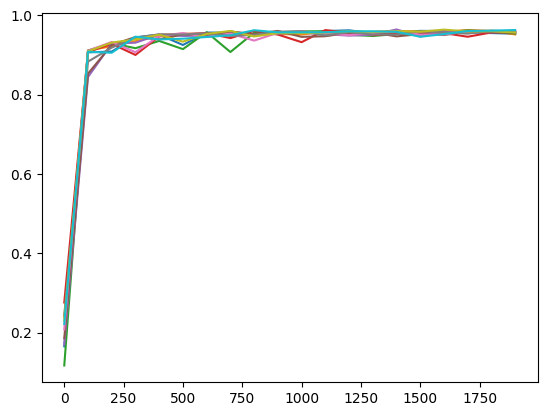

In [181]:
import matplotlib.pyplot as plt

_ = plt.plot(steps, accuracies)

In [182]:
def predict(X):
    predictions = jax.vmap(model.apply, in_axes=(0, None))(states, X).argmax(-1)
    return predictions.T

In [183]:
predictions = predict(X_test)

In [184]:
predictions.var(-1).argmax()

Array(4874, dtype=int32)

In [185]:
predictions[4874]

Array([9, 0, 0, 7, 9, 9, 0, 0, 9, 9], dtype=int32)

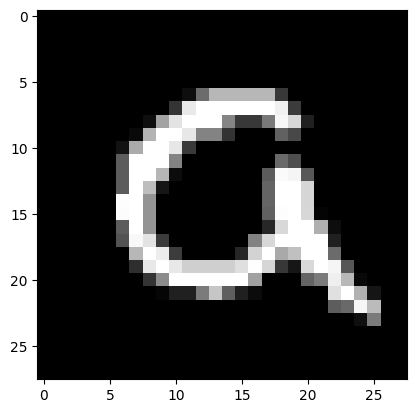

In [186]:
plt.imshow(X_test[4874].reshape(28,28), cmap="gray")

<BarContainer object of 10 artists>

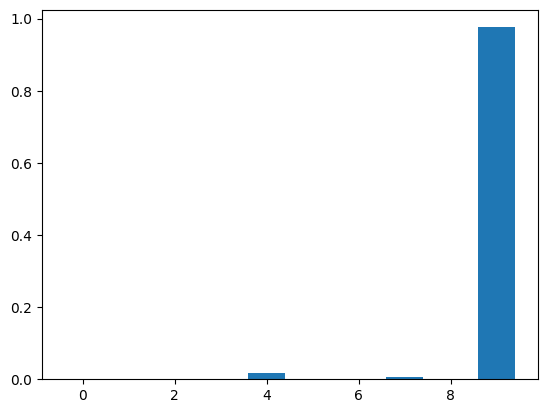

In [46]:
plt.bar(jnp.arange(10),predictions[9])